In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [27]:
df = pd.read_csv('heart.csv')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1061 non-null   int64  
 1   Sex             1061 non-null   object 
 2   ChestPainType   1061 non-null   object 
 3   RestingBP       1061 non-null   int64  
 4   Cholesterol     1061 non-null   int64  
 5   FastingBS       1061 non-null   int64  
 6   RestingECG      1061 non-null   object 
 7   MaxHR           1061 non-null   int64  
 8   ExerciseAngina  1061 non-null   object 
 9   Oldpeak         1061 non-null   float64
 10  ST_Slope        1061 non-null   object 
 11  HeartDisease    1061 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 99.6+ KB


In [29]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000
mean,53.691800,132.421301,202.864279,0.221489,137.774741,0.900848,0.555137
std,9.365846,18.072879,105.159468,0.415445,25.285412,1.097961,0.497185
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.000000,0.000000,120.000000,0.000000,0.000000
50%,55.000000,130.000000,222.000000,0.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,265.000000,0.000000,157.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [30]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1056,62,M,ATA,120,254,0,LVH,93,Y,0.0,Flat,1
1057,70,M,ASY,130,322,0,LVH,109,N,2.4,Flat,1
1058,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
1059,57,M,ATA,124,261,0,Normal,141,N,0.3,Up,1
1060,64,M,ASY,128,263,0,Normal,105,Y,0.2,Flat,0


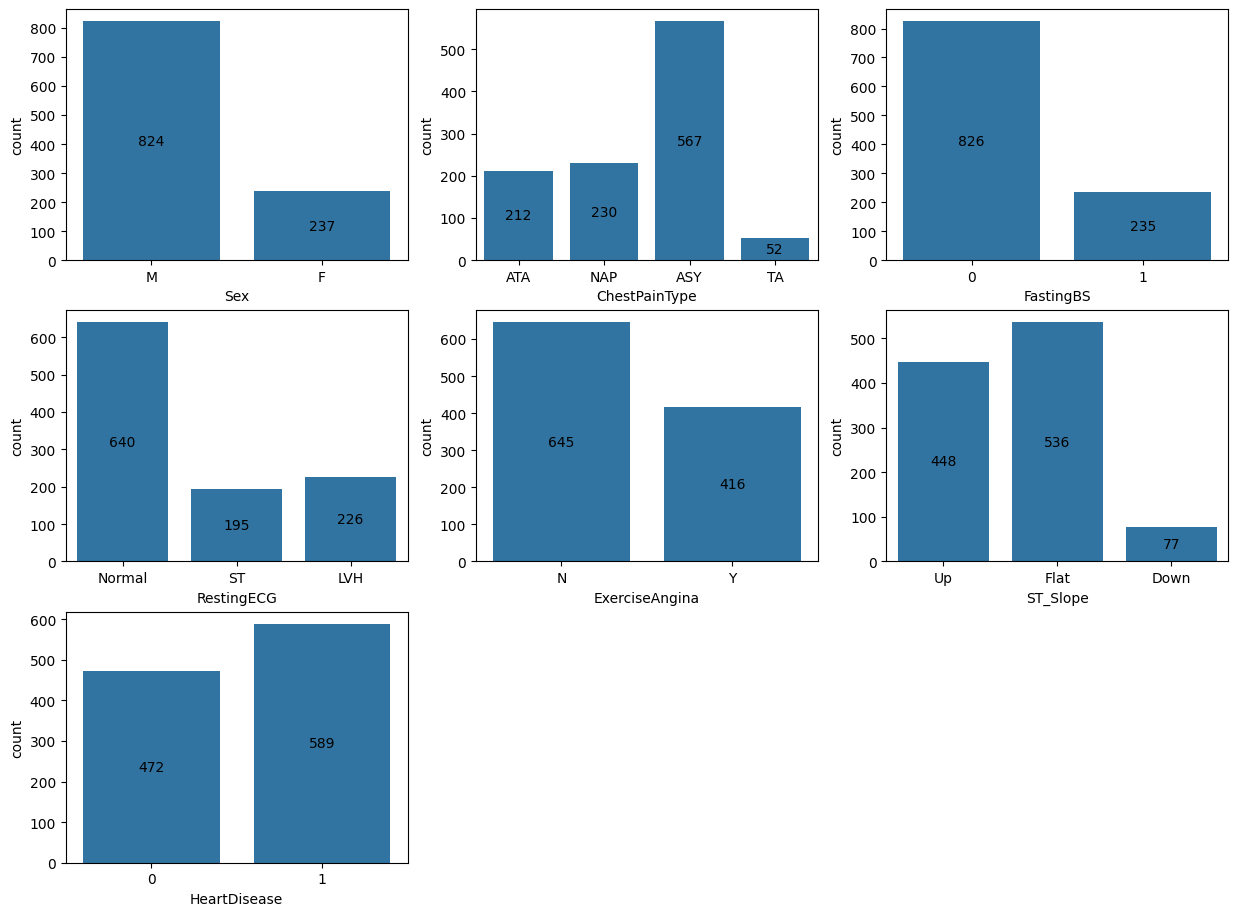

In [31]:
categorical = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

fig = plt.figure(figsize=(15,15))

for index, column in enumerate(categorical):
    ax = plt.subplot(4,3,index + 1)
    sns.countplot(x=df[column], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

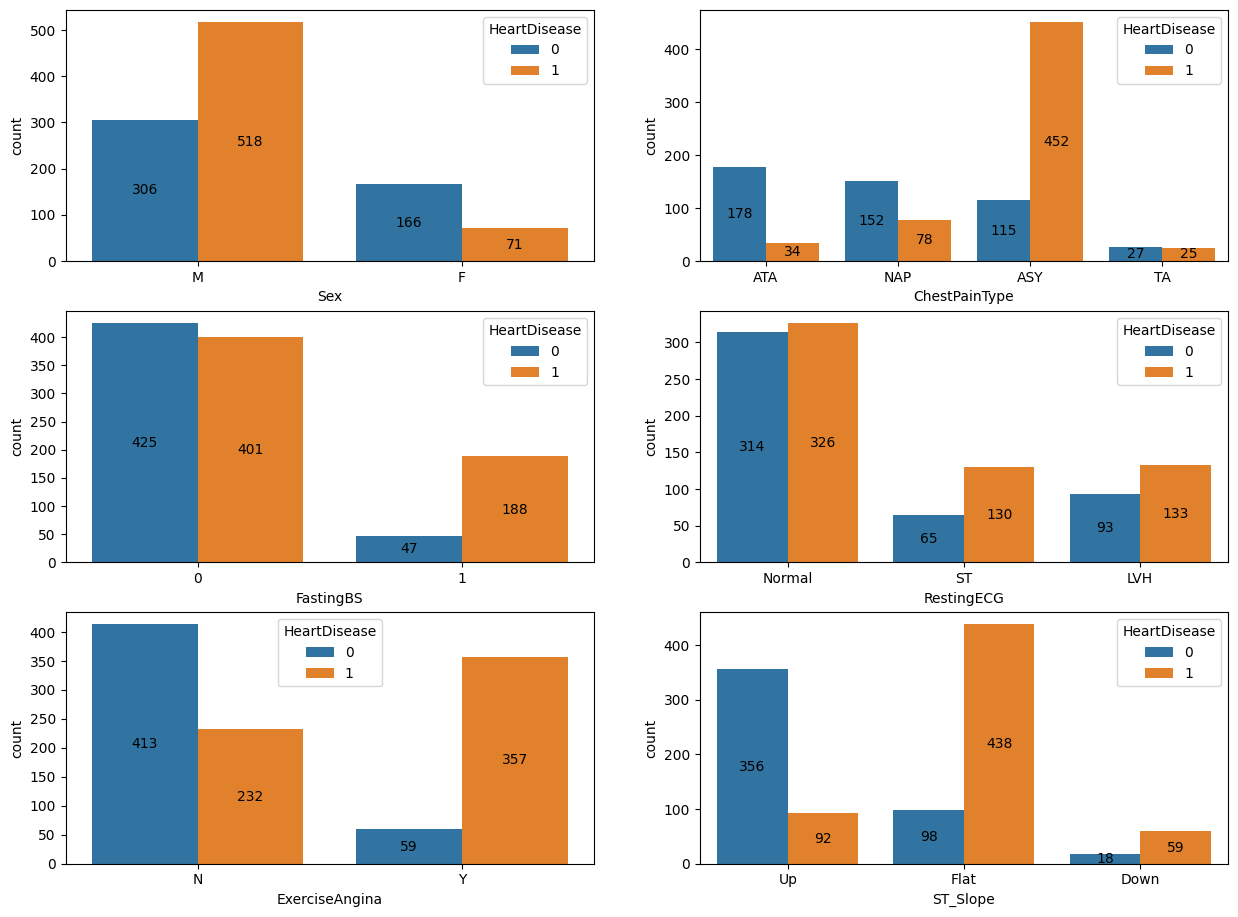

In [32]:
fig =plt.figure(figsize=(15,15))

for index, column in enumerate(categorical[:-1]):
    ax= plt.subplot(4, 2, index +1)
    sns.countplot(x=df[column], hue=df['HeartDisease'], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

In [33]:
df[df['RestingBP']==0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 449 to 449
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1 non-null      int64  
 1   Sex             1 non-null      object 
 2   ChestPainType   1 non-null      object 
 3   RestingBP       1 non-null      int64  
 4   Cholesterol     1 non-null      int64  
 5   FastingBS       1 non-null      int64  
 6   RestingECG      1 non-null      object 
 7   MaxHR           1 non-null      int64  
 8   ExerciseAngina  1 non-null      object 
 9   Oldpeak         1 non-null      float64
 10  ST_Slope        1 non-null      object 
 11  HeartDisease    1 non-null      int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 104.0+ bytes


In [34]:
df[df['Cholesterol']==0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 174 entries, 293 to 1039
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             174 non-null    int64  
 1   Sex             174 non-null    object 
 2   ChestPainType   174 non-null    object 
 3   RestingBP       174 non-null    int64  
 4   Cholesterol     174 non-null    int64  
 5   FastingBS       174 non-null    int64  
 6   RestingECG      174 non-null    object 
 7   MaxHR           174 non-null    int64  
 8   ExerciseAngina  174 non-null    object 
 9   Oldpeak         174 non-null    float64
 10  ST_Slope        174 non-null    object 
 11  HeartDisease    174 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 17.7+ KB


In [35]:
df_clean = df.copy()

df_clean = df_clean[df_clean['RestingBP'] != 0]

heartdisease_mask = df_clean['HeartDisease'] == 0

cholesterol_without_heartdisease = df_clean.loc[heartdisease_mask, 'Cholesterol']
cholesterol_with_heartdisease = df_clean.loc[~heartdisease_mask, 'Cholesterol'] 

df_clean.loc[heartdisease_mask, 'Cholesterol'] = cholesterol_without_heartdisease.replace(to_replace = 0, value = cholesterol_without_heartdisease.median())
df_clean.loc[~heartdisease_mask, 'Cholesterol'] = cholesterol_with_heartdisease.replace(to_replace = 0, value = cholesterol_with_heartdisease.median())

/var/folders/5j/qqm2kq850d75ctgf6wkbn7f80000gn/T/ipykernel_89169/4035528597.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[289.  283.  195.  339.  237.  208.  284.  211.  204.  211.  273.  201.
 223.  184.  201.  215.  209.  260.  284.  468.  188.  167.  186.  254.
 250.  177.  227.  230.  264.  259.  318.  223.  216.  340.  224.  245.
 180.  194.  365.  253.  254.  224.  202.  260.  297.  225.  412.  215.
 218.  163.  167.  100.  277.  238.  196.  216.  229.  208.  307.  210.
 182.  207.  147.   85.  269.  179.  260.  254.  214.  129.  241.  188.
 276.  297.  207.  160.  272.  240.  230.  246.  161.  163.  230.  228.
 292.  294.  215.  241.  243.  273.  198.  249.  168.  215.  159.  275.
 270.  291.  185.  195.  263.  196.  225.  238.  222.  179.  243.  235.
 320.  187.  287.  194.  238.  224.  238.  312.  251.  328.  280.  209.
 245.  192.  184.  193.  297.  268.  308.  249.  230.  147.  219.  1

In [36]:
df_clean[['Cholesterol', 'RestingBP']].describe()

,Cholesterol,RestingBP
count,1060.000000,1060.000000
mean,238.632075,132.546226
std,55.363572,17.617131
min,85.000000,80.000000
25%,211.000000,120.000000
50%,224.000000,130.000000
75%,265.000000,140.000000
max,603.000000,200.000000


In [37]:
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


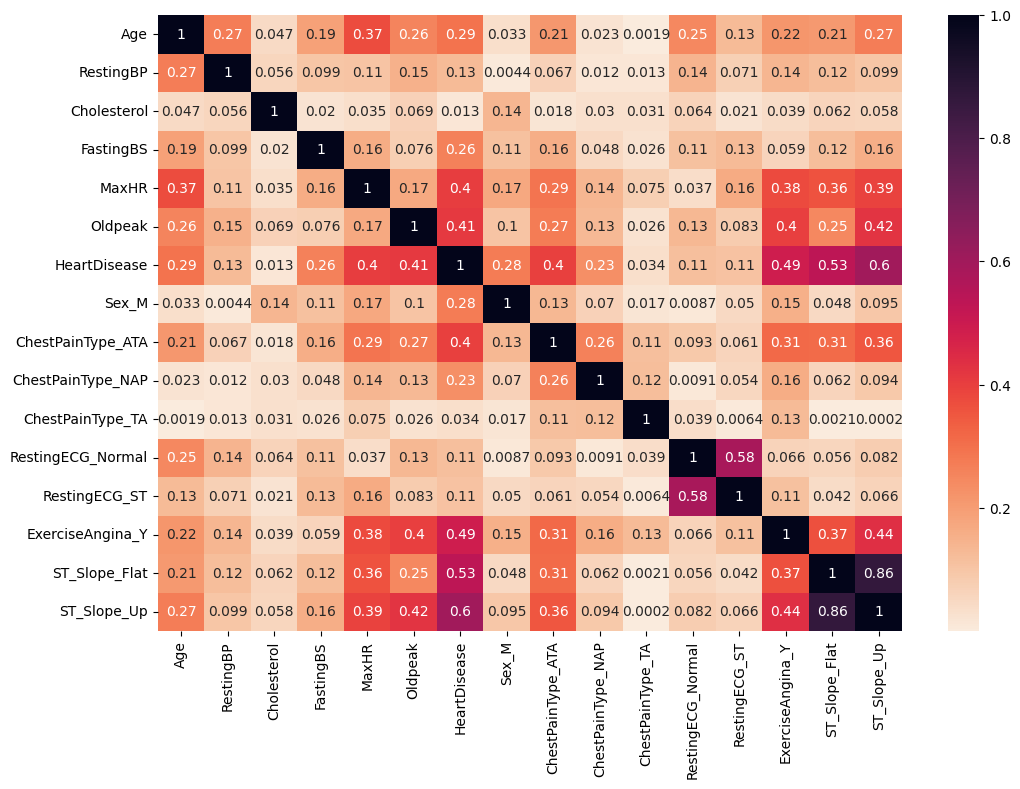

In [38]:
correlations = abs(df_clean.corr())
plt.figure(figsize=(12,8))
sns.heatmap(correlations, annot=True, cmap='rocket_r')
plt.show()

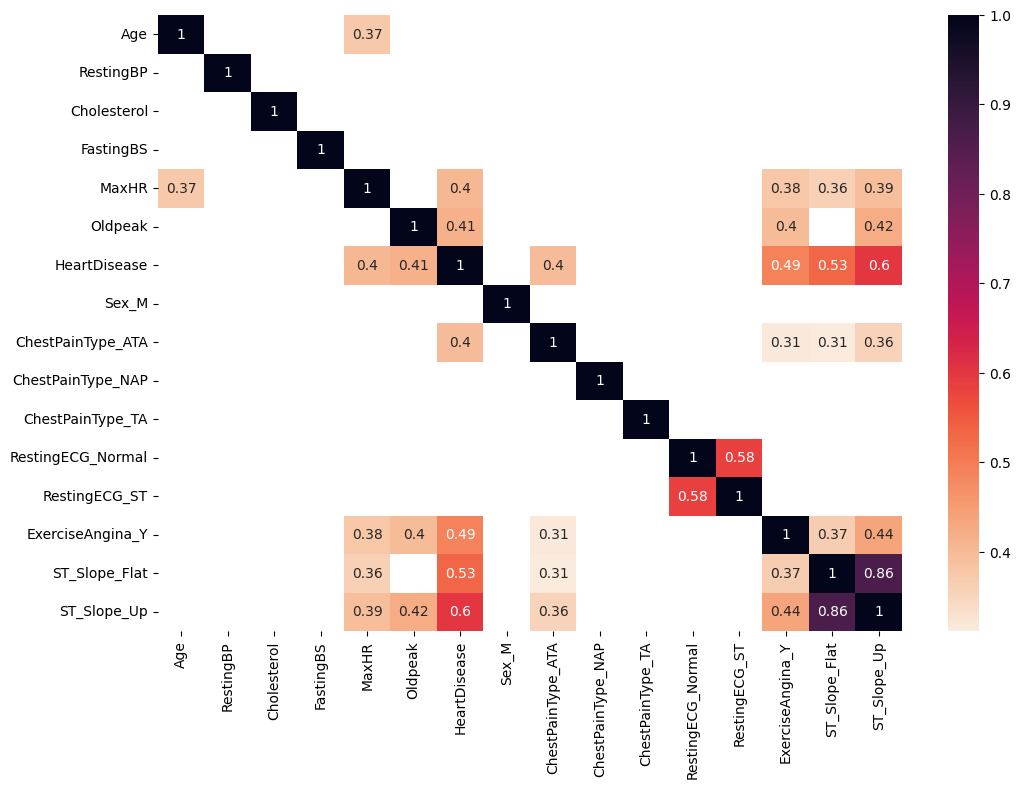

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(correlations[correlations>0.3], annot=True, cmap='rocket_r')
plt.show()

In [40]:
# splitting data
X = df_clean.drop(['HeartDisease'], axis=1)
y = df_clean['HeartDisease']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state= 417)

In [41]:
features = ['MaxHR','Oldpeak', 'Sex_M', 'ExerciseAngina_Y', "ST_Slope_Flat", 'ST_Slope_Up']

for feature in features:
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train[[feature]], y_train)
    accuracy = knn.score(X_val[[feature]], y_val)
    print(f'The k-NN classifier trained on {feature} and with k = 3 has an accuracy of {accuracy*100:.2f}%')

The k-NN classifier trained on MaxHR and with k = 3 has an accuracy of 63.21%
The k-NN classifier trained on Oldpeak and with k = 3 has an accuracy of 67.92%
The k-NN classifier trained on Sex_M and with k = 3 has an accuracy of 63.68%
The k-NN classifier trained on ExerciseAngina_Y and with k = 3 has an accuracy of 54.25%
The k-NN classifier trained on ST_Slope_Flat and with k = 3 has an accuracy of 54.25%
The k-NN classifier trained on ST_Slope_Up and with k = 3 has an accuracy of 80.19%


In [42]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_val_scaled = scaler.transform(X_val[features])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_val_scaled, y_val)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 84.43%


In [43]:
X = df_clean.drop(["HeartDisease"], axis=1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=417)

features = ['MaxHR', 
            'Oldpeak', 
            'ExerciseAngina_Y',
            #'Sex_M', 
            "ST_Slope_Flat", 
            "ST_Slope_Up"]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_train_scaled

array([[0.80597015, 0.43902439, 0.        , 0.        , 0.        ],
       [0.3880597 , 0.45121951, 1.        , 1.        , 0.        ],
       [0.56716418, 0.31707317, 1.        , 1.        , 0.        ],
       ...,
       [0.44029851, 0.56097561, 1.        , 0.        , 0.        ],
       [0.2761194 , 0.51219512, 1.        , 0.        , 1.        ],
       [0.63432836, 0.63414634, 0.        , 1.        , 0.        ]])

In [44]:
grid_params = {"n_neighbors": range(1,20),
               "metric": ['minkowski', 'manhattan']}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train);
knn_grid.best_score_*100, knn_grid.best_params_

(np.float64(84.19631047685347), {'metric': 'manhattan', 'n_neighbors': 5})

In [45]:
X_test_scaled = scaler.transform(X_test[features])
predictions = knn_grid.best_estimator_.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f"Model accuracy on test: {accuracy*100:.2f}%")

Model accuracy on test: 82.55%


In [46]:
# check data distribution
print("Distribution of patients by their sex in the entire dataset")
print(X.Sex_M.value_counts()) 

Distribution of patients by their sex in the entire dataset
Sex_M
True     823
False    237
Name: count, dtype: int64


In [47]:
print("Distribution of patients by their sex int the training dataset")
print(X_train.Sex_M.value_counts())

Distribution of patients by their sex int the training dataset
Sex_M
True     663
False    185
Name: count, dtype: int64


In [48]:
print('Distribution of patients by their sex in the test dataset')  
print(X_test.Sex_M.value_counts())

Distribution of patients by their sex in the test dataset
Sex_M
True     160
False     52
Name: count, dtype: int64


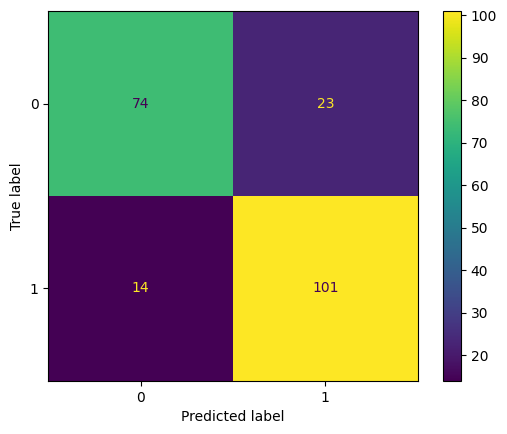

In [49]:
cf = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cf).plot()
plt.show()